In [1]:
# importing sys
import sys
# This is how you import modules that exist outside of working directory 
# adding mosaique to the system path
sys.path.insert(1, '/home/aasmai/work/QML-QPF/mosaiQue') 
import mosaique as mq
import scipy
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras
import matplotlib.pyplot as plt
# import tensorrt as trt
import tensorflow as tf

2025-11-28 22:50:56.406090: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 22:50:56.445156: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-28 22:50:56.950631: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:

print(f' tensorflow version {tf.__version__}')

# print(f' tensorrt version {trt.__version__}')

print(tf.config.list_physical_devices('GPU'))

 tensorflow version 2.16.1
[]


2025-11-28 22:50:57.418501: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
# pip install medmnist

In [4]:
from medmnist import DermaMNIST
train_data = DermaMNIST(split="train", download=True,size=64)
test_data = DermaMNIST(split="test", download=True,size=64)
# name of the folder where will save the filtered images for training
# kernel shape OA
kernel_shape = [3,1]
tr_layer = mq.ConvolutionLayer4x4("_OA_3qbits_results_DermaMNIST_train", kernel_shape)
# name of the folder where will save the filtered images for testing
te_layer = mq.ConvolutionLayer4x4("_OA_3qbits_results_DermaMNIST_test", kernel_shape)


#load the data set want to train
(tr_images, tr_labels), (te_images, te_labels) = (train_data.imgs, train_data.labels), (test_data.imgs, test_data.labels)
scaled_train_images, scaled_test_images = tr_images/255., te_images/255.

In [5]:
# pip install tqdm

In [6]:
import numpy as np
import pennylane as qml
import tensorflow as tf
import time
from tqdm import tqdm

def process_with_precompute_and_vectorization(scaled_train_images, saving_folder_name):
    """Combine precomputation with TensorFlow vectorization for maximum speed"""
    nb_qbits = 3
    dev = qml.device("default.qubit", wires=nb_qbits)
    
    @qml.qnode(dev, interface='tf', diff_method=None)
    @tf.autograph.experimental.do_not_convert  # Add this to silence warnings
    def circuit(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs, wires=range(nb_qbits), rotation='Y')
        qml.CNOT(wires=[0, 2])
        qml.CNOT(wires=[1, 2])
        qml.CNOT(wires=[2, 0])
        return [qml.expval(qml.PauliZ(j)) for j in range(nb_qbits)]
    
    # Create a vectorized version that properly returns tensors
    # @tf.function
    # def vectorized_circuit(batch_inputs):
    #     return tf.stack([circuit(x) for x in batch_inputs])
    #     # Alternative if tf.vectorized_map is causing issues:
    #     # return tf.map_fn(lambda x: circuit(x), batch_inputs)
    
    
    @tf.function
    def process_batch(inputs):
        """Process a batch of inputs using vectorized_map"""
        return tf.stack(tf.vectorized_map(circuit, inputs), axis=1)
    
    # Find unique pixel values (with tolerances to reduce unique count)
    decimal_precision = 4  # This will affect our data
    flat_pixels = scaled_train_images.reshape(-1, scaled_train_images.shape[-1])
    rounded_pixels = np.round(flat_pixels, decimal_precision)
    
    unique_pixels, inverse_indices = np.unique(rounded_pixels, axis=0, return_inverse=True)
    print(f"Found {len(unique_pixels)} unique pixel values out of {len(flat_pixels)} total pixels")
    
    # Process all unique pixels in batches
    batch_size = 1000  # Adjust based on your memory
    unique_results = []
    
    print("Processing unique pixel values...")
    start_time = time.time()
    
    for i in range(0, len(unique_pixels), batch_size):
        batch = unique_pixels[i:min(i+batch_size, len(unique_pixels))]
        batch_tensor = tf.convert_to_tensor(batch, dtype=tf.float32)
        
        # Process the batch and convert to numpy right away
        batch_results = tf.convert_to_tensor(process_batch(batch_tensor)).numpy()
        unique_results.append(batch_results)
    
    # Combine results
    unique_outputs = np.vstack(unique_results)
    
    print(f"Unique pixel processing completed in {time.time() - start_time:.2f} seconds")
    
    # Rest of the function remains the same...
    # Map the results back to the original images
    sample_size = min(7007, scaled_train_images.shape[0])
    height, width, channels = scaled_train_images.shape[1:]
    all_samples_results = np.empty((sample_size, height, width, 3))
    
    print("Mapping results back to images...")
    start_mapping = time.time()
    
    # Reshape inverse indices to map back to original images
    total_pixels = height * width
    
    for s in tqdm(range(sample_size)):
        # Get the indices for this image
        img_start = s * total_pixels
        img_end = img_start + total_pixels
        img_indices = inverse_indices[img_start:img_end]
        
        # Map results using the indices
        img_results = unique_outputs[img_indices]
        
        # Reshape back to image dimensions
        all_samples_results[s] = img_results.reshape(height, width, 3)
    
    print(f"Mapping completed in {time.time() - start_mapping:.2f} seconds")
    print(f"Total processing time: {time.time() - start_time:.2f} seconds")
    
    # Save the processed data
    log_dir = saving_folder_name + "/"
    log_file =  log_dir + "02-12-20" # this is the CNOT gate configuration
    os.makedirs(log_dir, exist_ok=True)
    np.save(log_file, all_samples_results)
    print(f"Data saved to: {log_file}")
    
    return all_samples_results

In [7]:
train_processed_filename = "results_train_quantum_processed_DermaMnist"
process_with_precompute_and_vectorization(scaled_train_images, train_processed_filename)
test_processed_filename = "results_test_quantum_processed_DermaMnist"
process_with_precompute_and_vectorization(scaled_test_images, test_processed_filename)

Found 1453867 unique pixel values out of 28700672 total pixels
Processing unique pixel values...
Unique pixel processing completed in 1.80 seconds
Mapping results back to images...


100%|██████████| 7007/7007 [00:00<00:00, 11425.86it/s]


Mapping completed in 0.62 seconds
Total processing time: 2.42 seconds
Data saved to: results_train_quantum_processed_DermaMnist/02-12-20
Found 1059688 unique pixel values out of 8212480 total pixels
Processing unique pixel values...
Unique pixel processing completed in 1.33 seconds
Mapping results back to images...


100%|██████████| 2005/2005 [00:00<00:00, 12112.12it/s]

Mapping completed in 0.17 seconds
Total processing time: 1.50 seconds


Data saved to: results_test_quantum_processed_DermaMnist/02-12-20


array([[[[ 3.63071726e-01, -6.12410439e-01, -3.54177882e-01],
         [ 3.56845781e-01, -6.12410463e-01, -3.49040083e-01],
         [ 3.56845781e-01, -6.12410463e-01, -3.49040083e-01],
         ...,
         [ 2.39266766e-01, -4.78446759e-01, -2.28887523e-01],
         [ 2.44629042e-01, -4.89169365e-01, -2.34017186e-01],
         [ 2.50090653e-01, -5.00090606e-01, -2.39241876e-01]],

        [[ 3.57302376e-01, -6.02679001e-01, -3.48549859e-01],
         [ 3.63071744e-01, -6.12410468e-01, -3.55129858e-01],
         [ 3.51175371e-01, -6.02679037e-01, -3.44384526e-01],
         ...,
         [ 2.23746729e-01, -4.67652272e-01, -2.11477754e-01],
         [ 2.28435198e-01, -4.56787551e-01, -2.15909135e-01],
         [ 2.55377837e-01, -5.00090650e-01, -2.43369807e-01]],

        [[ 3.21896689e-01, -5.82690531e-01, -3.12182161e-01],
         [ 3.10499582e-01, -5.72689780e-01, -3.01129007e-01],
         [ 3.27823467e-01, -5.82690562e-01, -3.20652607e-01],
         ...,
         [ 2.34041547e-0

Data loaded successfully from: /home/aasmai/work/QML-QPF/RGB/DermaMnist/Notebooks/results_train_quantum_processed_DermaMnist/02-12-20.npy
Loaded data shape: (7007, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


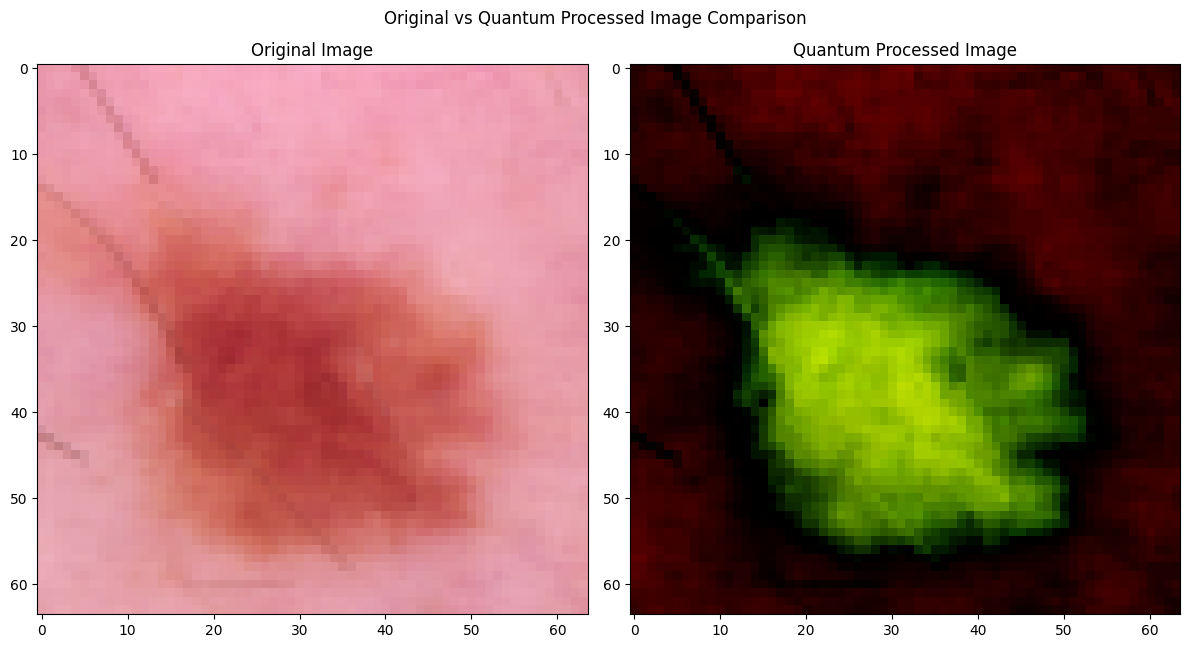

Original image range: 0.1607843137254902 to 0.984313725490196
Processed image range: -0.5421776325899582 to 0.8750931854575843


In [8]:
import os
def data_load_from_file(folder_name, file_name):
    file_name += ".npy"
    # Construct the full path to the file inside the folder
    file_path = os.path.join(os.getcwd(), folder_name, file_name)   
    try:
        # Load the data using NumPy's load function
        processed_data = np.load(file_path)
        print(f"Data loaded successfully from: {file_path}")
        print(f"Loaded data shape: {processed_data.shape}")
        # Now you can work with the 'loaded_data' array
        return processed_data
    except FileNotFoundError:
        print(f"Error: File not found at: {file_path}")
    except Exception as e:
        print(f"An error occurred while loading the file: {e}")
        
        
        
# folder_name = train_processed_filename  # Replace with the actual name of your folder
# file_name = "02-12-20" + ".npy"

# filename = train_processed_filename + "/" + "02-12-20" + '.npy'
# Load the processed data
train_processed_filename = "results_train_quantum_processed_DermaMnist"
test_processed_filename = "results_test_quantum_processed_DermaMnist"

processed_data = data_load_from_file(train_processed_filename, "02-12-20")

# Select the image_indxth image from each dataset
image_indx = -1
processed_image = processed_data[image_indx]
original_image = scaled_train_images[image_indx]  

# Create a side-by-side comparison
plt.figure(figsize=(12, 6))

# Display original image
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
# plt.colorbar()
plt.axis('on')

# Display processed image
plt.subplot(1, 2, 2)
plt.imshow(processed_image)
plt.title("Quantum Processed Image")
# plt.colorbar()
plt.axis('on')

plt.tight_layout()
plt.suptitle("Original vs Quantum Processed Image Comparison", y=1.05)
plt.show()

# Print value ranges for both images
print(f"Original image range: {original_image.min()} to {original_image.max()}")
print(f"Processed image range: {processed_image.min()} to {processed_image.max()}")

In [9]:
# OA way of changing brain's code to fit the 3quibts 
# we don't need the permutations
# permutations perpares different configuration of entanglement
permutations = np.asarray(list(itertools.permutations(range(4))))

def pool(x, call, p, l):
    # This func. will be passed to excutor 
    # op is the operation layer that has the quantum layer + keras model
    op = OperationLayer(call())
    # pre_op.predict(x,batch_size=1000) 
    # Initializes and returns a custom Keras model used to preprocess images.
    # Returns:
    #     keras.Model: A compiled Keras model for image preprocessing
    # post_transform
    # X (np.ndarray): Transformed data of shape [batch_size, number_of_patches, patch_size].
    # Returns:
    # np.ndarray: Reconstructed image data of shape [batch_size, height, width, channels].
    # we're replacing the posttransform because it only deals with 2.2 kernel
    # predict = l.post_transform(op.pre_op.predict(x,batch_size=1000))
    predict = op.pre_op.predict(x,batch_size=1000)
    N, h, w, c = l._kernel.input_shape 
    predict = predict.reshape(N, h, w, c)
    l.save(predict, p)

# CNN Model

In [ ]:
from keras.callbacks import CSVLogger

def run(tr_images, te_images,label):
    log_dir =  os.path.join(os.getcwd(),train_processed_filename, "run")
    log_file =  os.path.join(log_dir, label + ".csv")
    os.makedirs(log_dir, exist_ok=True)
    
    csv_logger = CSVLogger(log_file)
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_file,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    
    input_data_shape = tr_images.shape[1:]
    number_of_classes = len(np.unique(tr_labels))
    # Build CNN model
    # Model 1 that we have the first accuracy output  epochs=60
    # q_model = models.Sequential([
    # layers.Conv2D(32, (3,3), activation='relu', input_shape=input_data_shape),
    # layers.MaxPooling2D((2,2)),
    # layers.Conv2D(64, (3,3), activation='relu'),
    # layers.MaxPooling2D((2,2)),
    # layers.Flatten(),
    # layers.Dense(64, activation='relu'),
    # layers.Dense(number_of_classes, activation='softmax')
    # ])
    
    q_model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_data_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # Adding dropout for regularization
        layers.Dense(number_of_classes, activation='softmax')
    ])

    # Compile the model
    q_model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
    
    # q_model = keras.models.Sequential([
    #     keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
    #     keras.layers.Flatten(),
    #     keras.layers.Dense(250, activation='relu'),
    #     keras.layers.Dense(len(np.unique(test_labels)), activation="softmax")
    # ])
    # q_model.compile(
    #     optimizer='adam',
    #     loss="sparse_categorical_crossentropy",
    #     metrics=["accuracy"],
    # )

    q_history = q_model.fit(
        tr_images,
        tr_labels,
        validation_data=(te_images, te_labels),
        batch_size=128,
        epochs=5000,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = csv_logger
    )

def model(tr_folder_name, te_folder_name, label="02-12-20"):
    # Load the processed data
    tr_images = data_load_from_file(tr_folder_name,label)

    te_images = data_load_from_file(te_folder_name,label)
    run(tr_images, te_images, label)

In [11]:
train_processed_filename = "results_train_quantum_processed_DermaMnist"
test_processed_filename = "results_test_quantum_processed_DermaMnist"

In [12]:
model(train_processed_filename, test_processed_filename)

Data loaded successfully from: /home/aasmai/work/QML-QPF/RGB/DermaMnist/Notebooks/results_train_quantum_processed_DermaMnist/02-12-20.npy
Loaded data shape: (7007, 64, 64, 3)
Data loaded successfully from: /home/aasmai/work/QML-QPF/RGB/DermaMnist/Notebooks/results_test_quantum_processed_DermaMnist/02-12-20.npy
Loaded data shape: (2005, 64, 64, 3)


NameError: name 'models' is not defined

In [ ]:
# run the network without filter

# run(tr_images,te_images,"NO-FILTER")

# Read Validation accuracy 
Now we will read from the csv and group the experiment validation for the last 30 epoch into the symmetries

In [ ]:
import pandas as pd

val_accuracy = []


file = "results_train_quantum_processed_DermaMnist/run/02-12-20.csv"
# print(file)

#read the csv file
df = pd.read_csv(file)


val_accuracy.append(df['val_accuracy'].tail(30).tolist())
        
   


In [ ]:
# need to flatten the list to have all the data in a single list
val_accuracy_flattened = [item for sublist in val_accuracy for item in sublist]

In [ ]:
file = "results_train_quantum_processed_DermaMnist/run/NO-FILTER.csv"
df = pd.read_csv(file)
no_fitler_val_accuracy = df['val_accuracy'].tail(30).tolist()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combine the data into a list of lists
data = [val_accuracy_flattened,]

# Define the labels for the box plot
labels_plot = ['Accuracy']

# Create the box plot
# plt.boxplot(data, tick_labels=labels_plot)
plt.boxplot(data)


# Calculate the mean value of the no_filter list
mean_no_filter = np.mean(no_fitler_val_accuracy)

# Add a horizontal line at the mean value of no_filter
plt.axhline(y= mean_no_filter, color='r', linestyle='--', label=f'Mean No Filter: {mean_no_filter:.2f}')
# plt.ylim(0.01,.97)

# Add title and labels
plt.title('Box Plot of Val Accuracy')
# plt.xlabel('Symmetries')
plt.ylabel('Val Accuracy')

# Show the plot
plt.show()